                                                        Project Data Analysis !1

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [32]:
# Load the dataset using a relative path for portability in GitHub
import os
csv_path = os.path.join("..", "data", "results.csv")
data = pd.read_csv(csv_path)
data.head(50)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
5,1876-03-25,Scotland,Wales,4.0,0.0,Friendly,Glasgow,Scotland,False
6,1877-03-03,England,Scotland,1.0,3.0,Friendly,London,England,False
7,1877-03-05,Wales,Scotland,0.0,2.0,Friendly,Wrexham,Wales,False
8,1878-03-02,Scotland,England,7.0,2.0,Friendly,Glasgow,Scotland,False
9,1878-03-23,Scotland,Wales,9.0,0.0,Friendly,Glasgow,Scotland,False


In [33]:
data.isnull().sum()

date          0
home_team     0
away_team     0
home_score    7
away_score    7
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [34]:
# اسيتبدال القيم الفارغة في عمود home_score و away_score بمتوسط القيم في كل عمود

meann1=data['home_score'].mean()
meann2=data['away_score'].mean()
data["home_score"]= data["home_score"].fillna(meann1)
data["away_score"]= data["away_score"].fillna(meann2)

data.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [30]:
data.head(30)

,date,home_team,away_team,home_score,away_score,match_result,end_match_num,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Draw,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Home Win,1,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Home Win,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Draw,0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Home Win,1,Friendly,Glasgow,Scotland,False
5,1876-03-25,Scotland,Wales,4.0,0.0,Home Win,1,Friendly,Glasgow,Scotland,False
6,1877-03-03,England,Scotland,1.0,3.0,Away Win,-1,Friendly,London,England,False
7,1877-03-05,Wales,Scotland,0.0,2.0,Away Win,-1,Friendly,Wrexham,Wales,False
8,1878-03-02,Scotland,England,7.0,2.0,Home Win,1,Friendly,Glasgow,Scotland,False
9,1878-03-23,Scotland,Wales,9.0,0.0,Home Win,1,Friendly,Glasgow,Scotland,False


In [29]:
# استبدال القيم في العمود ب قيم تانيه

# data["neutral"] = data["neutral"].replace({False: 0 , True : 1})

# data["neutral"].map({True : "T" , False : "F"})

## 1. Advanced Feature Engineering

In this section, we parse match dates to extract datetime components and generate additional indicators such as total goals and goal difference.

In [ ]:
def match_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'
    
def end_match_num(row):
    if row["home_score"] > row["away_score"]:
        return 1
    if row["home_score"] < row["away_score"]:
        return -1
    else:
        return 0

#  حط الأعمدة في المكان اللي أنت عارفه بالظبط
#  تطبيق الدالتين لإنشاء العمودين الجديدين
#  بنستخدم axis=1 عشان يمر على صف صف في الجدول
data.insert(loc=5, column='match_result', value=data.apply(match_result, axis=1))

#  العمود التاني هيتحط في المكان 6 عشان ييجي بعد الأولاني على طول
data.insert(loc=6, column='end_match_num', value=data.apply(end_match_num, axis=1))

In [ ]:
# Convert date to datetime
data['date'] = pd.to_datetime(data['date'])

# Extract time-based features
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day_of_week'] = data['date'].dt.day_name()

# Calculate goals-based features
data['total_goals'] = data['home_score'] + data['away_score']
data['goal_difference'] = data['home_score'] - data['away_score']

print("Additional features created successfully!")
data.head(30)

Additional features created successfully!


,date,home_team,away_team,home_score,away_score,match_result,end_match_num,tournament,city,country,neutral,year,month,day_of_week,total_goals,goal_difference
0,1872-11-30,Scotland,England,0.0,0.0,Draw,0,Friendly,Glasgow,Scotland,False,1872,11,Saturday,0.0,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Home Win,1,Friendly,London,England,False,1873,3,Saturday,6.0,2.0
2,1874-03-07,Scotland,England,2.0,1.0,Home Win,1,Friendly,Glasgow,Scotland,False,1874,3,Saturday,3.0,1.0
3,1875-03-06,England,Scotland,2.0,2.0,Draw,0,Friendly,London,England,False,1875,3,Saturday,4.0,0.0
4,1876-03-04,Scotland,England,3.0,0.0,Home Win,1,Friendly,Glasgow,Scotland,False,1876,3,Saturday,3.0,3.0
5,1876-03-25,Scotland,Wales,4.0,0.0,Home Win,1,Friendly,Glasgow,Scotland,False,1876,3,Saturday,4.0,4.0
6,1877-03-03,England,Scotland,1.0,3.0,Away Win,-1,Friendly,London,England,False,1877,3,Saturday,4.0,-2.0
7,1877-03-05,Wales,Scotland,0.0,2.0,Away Win,-1,Friendly,Wrexham,Wales,False,1877,3,Monday,2.0,-2.0
8,1878-03-02,Scotland,England,7.0,2.0,Home Win,1,Friendly,Glasgow,Scotland,False,1878,3,Saturday,9.0,5.0
9,1878-03-23,Scotland,Wales,9.0,0.0,Home Win,1,Friendly,Glasgow,Scotland,False,1878,3,Saturday,9.0,9.0


## 2. Exploratory Data Analysis (EDA)

Let's dive into professional-grade visualizations and statistical summaries to uncover insights about international football history.

### 2.1 Match Outcomes & Home Advantage Analysis

We analyze the distribution of match outcomes to investigate the classic "Home Advantage" phenomenon in international football.

C:\Users\A\AppData\Local\Temp\ipykernel_16476\2262428083.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='match_result', palette='viridis', order=['Home Win', 'Away Win', 'Draw'])


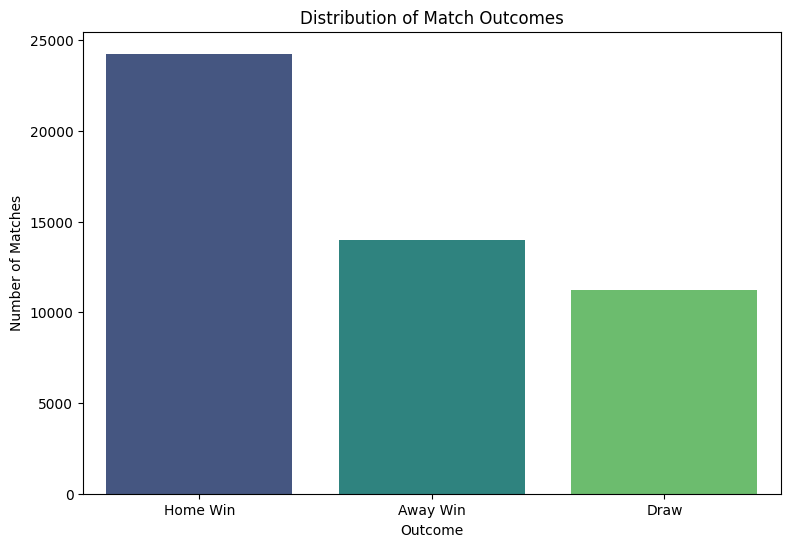

Match Outcome Percentages:
match_result
Home Win    49.014181
Away Win    28.247344
Draw        22.738475
Name: count, dtype: float64


In [51]:
# Visualizing the distribution of match outcomes
plt.figure(figsize=(9 , 6))

# بيغد عدد اتكرارات ورسمها ب مكنبة seaborn 
sns.countplot(data=data, x='match_result', palette='viridis', order=['Home Win', 'Away Win', 'Draw'])
plt.title('Distribution of Match Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Number of Matches')
plt.show()

# Calculate percentages
outcome_counts = data['match_result'].value_counts()
print("Match Outcome Percentages:")
print(outcome_counts / len(data) * 100)

### 2.2 Goal Scoring Trends Over Time

How has the average number of goals scored per match changed since the beginning of international football in 1872?

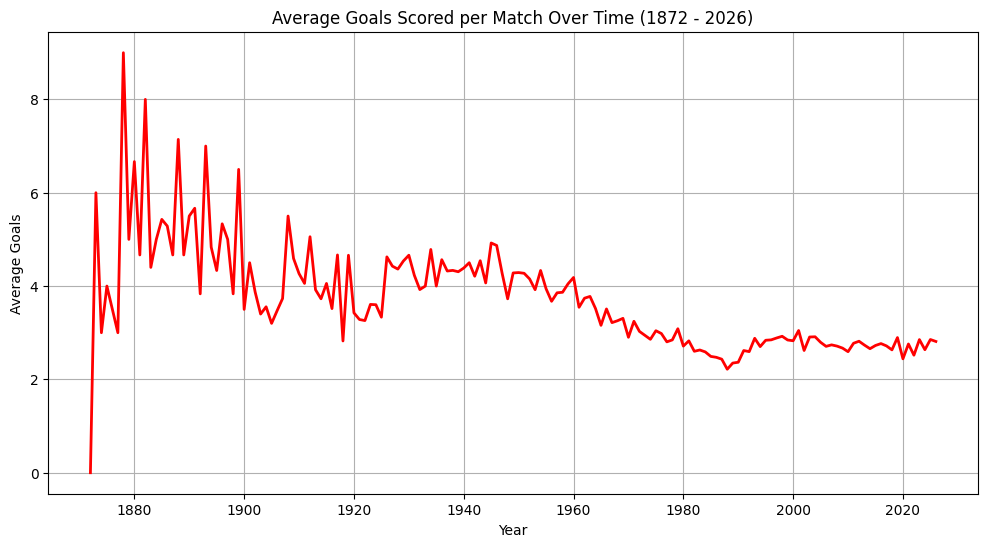

In [56]:
# Average goals per match over the years
goals_by_year = data.groupby('year')['total_goals'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=goals_by_year, x='year', y='total_goals', color='red', linewidth=2)
plt.title('Average Goals Scored per Match Over Time (1872 - 2026)')
plt.xlabel('Year')
plt.ylabel('Average Goals')
plt.grid(True)
plt.show()

### 2.3 Top 10 Most Active Teams

Which countries have played the most international fixtures in history?

C:\Users\A\AppData\Local\Temp\ipykernel_16476\1110741407.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_teams, x='matches_played', y='team', palette='magma')


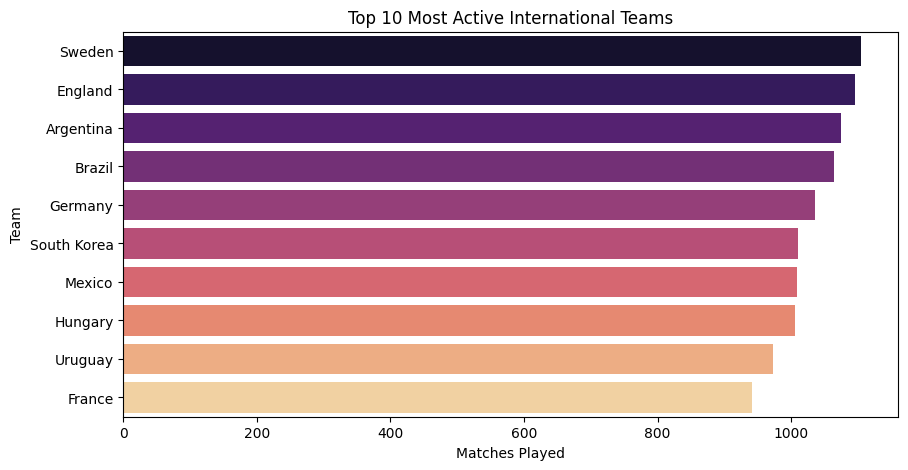

In [57]:
# Combined list of all home and away appearances
all_teams = pd.concat([data['home_team'], data['away_team']])
active_teams = all_teams.value_counts().head(10).reset_index()
active_teams.columns = ['team', 'matches_played']

plt.figure(figsize=(10, 5))
sns.barplot(data=active_teams, x='matches_played', y='team', palette='magma')
plt.title('Top 10 Most Active International Teams')
plt.xlabel('Matches Played')
plt.ylabel('Team')
plt.show()

### 2.4 Top 10 Most Successful Teams (Total Wins)

Which national teams have registered the most victories in international football?

C:\Users\A\AppData\Local\Temp\ipykernel_16476\2654985552.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=winners, x='wins', y='team', palette='rocket')


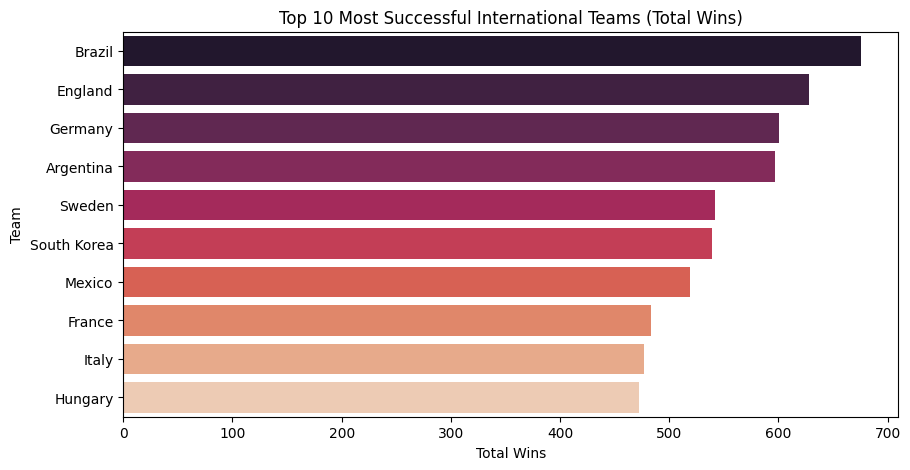

In [58]:
# Function to determine winner of a match
def get_winner(row):
    if row['match_result'] == 'Home Win':
        return row['home_team']
    elif row['match_result'] == 'Away Win':
        return row['away_team']
    else:
        return 'Draw'

data['winner'] = data.apply(get_winner, axis=1)

# Exclude Draws and count wins
winners = data[data['winner'] != 'Draw']['winner'].value_counts().head(10).reset_index()
winners.columns = ['team', 'wins']

plt.figure(figsize=(10, 5))
sns.barplot(data=winners, x='wins', y='team', palette='rocket')
plt.title('Top 10 Most Successful International Teams (Total Wins)')
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.show()

### 2.5 Neutral Ground vs. Home Ground Impact

Does playing on a neutral venue eliminate the Home Win advantage?

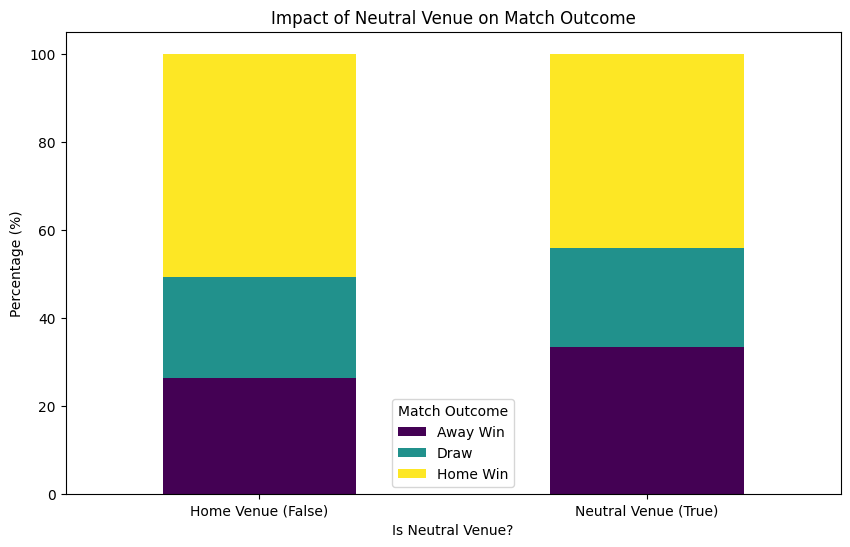

match_result   Away Win       Draw   Home Win
neutral                                      
False         26.397140  22.852035  50.750825
True          33.366306  22.424289  44.209405


In [59]:
# Analyze how playing on neutral ground affects match results
neutral_analysis = data.groupby('neutral')['match_result'].value_counts(normalize=True).unstack() * 100

neutral_analysis.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Impact of Neutral Venue on Match Outcome')
plt.xlabel('Is Neutral Venue?')
plt.ylabel('Percentage (%)')
plt.legend(title='Match Outcome')
plt.xticks([0, 1], ['Home Venue (False)', 'Neutral Venue (True)'], rotation=0)
plt.show()

print(neutral_analysis)

### 2.6 Goal Distribution & Historical Highs

Let's look at the distribution of total goals per match and discover the highest-scoring matches in football history.

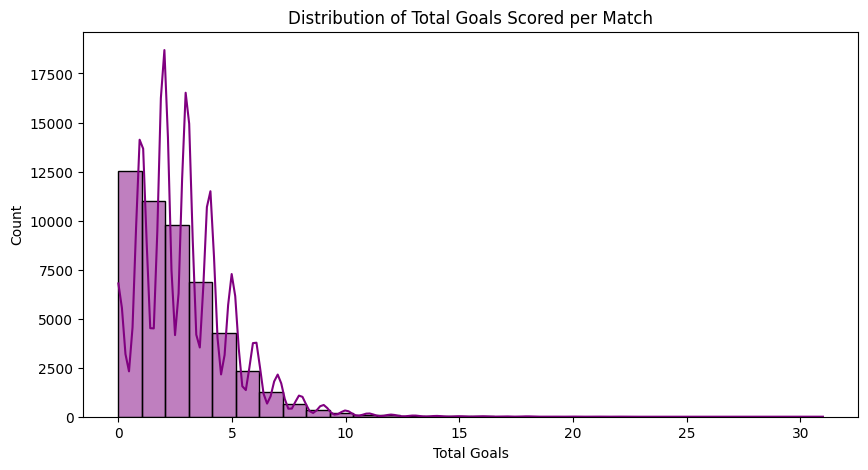

Top 5 Highest Scoring Matches in History:


,date,home_team,away_team,home_score,away_score,total_goals,tournament
25425,2001-04-11,Australia,American Samoa,31.0,0.0,31.0,FIFA World Cup qualification
8551,1971-09-13,Tahiti,Cook Islands,30.0,0.0,30.0,South Pacific Games
11916,1979-08-30,Fiji,Kiribati,24.0,0.0,24.0,South Pacific Games
25422,2001-04-09,Australia,Tonga,22.0,0.0,22.0,FIFA World Cup qualification
30518,2006-11-24,Sápmi,Monaco,21.0,1.0,22.0,Viva World Cup


In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='total_goals', bins=30, kde=True, color='purple')
plt.title('Distribution of Total Goals Scored per Match')
plt.xlabel('Total Goals')
plt.ylabel('Count')
plt.show()

# Show the highest scoring matches
highest_scoring = data.nlargest(5, 'total_goals')[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'total_goals', 'tournament']]
print("Top 5 Highest Scoring Matches in History:")
highest_scoring

### 2.7 Tournament Analysis

Which tournaments dominate the dataset in terms of match counts?

C:\Users\A\AppData\Local\Temp\ipykernel_16476\1309702.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tournaments, x='match_count', y='tournament', palette='mako')


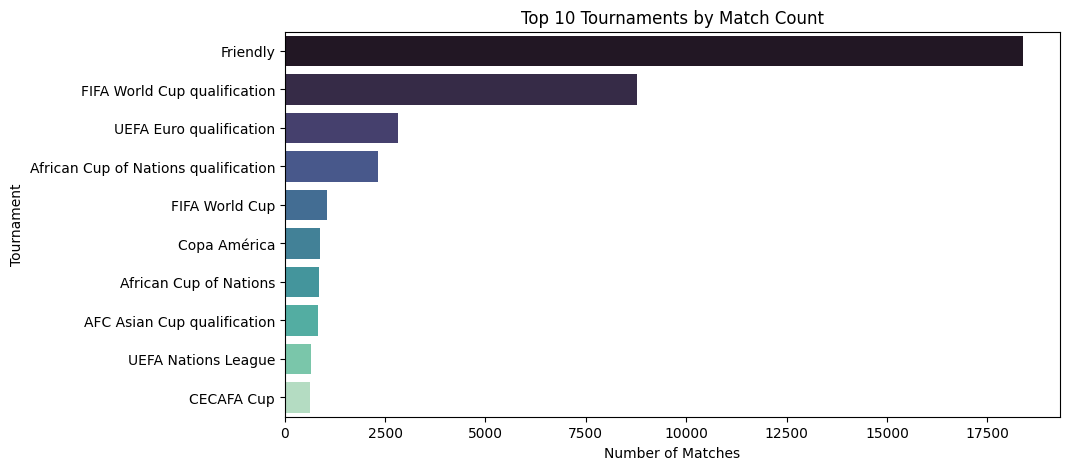

In [61]:
# Show top tournaments by number of matches
top_tournaments = data['tournament'].value_counts().head(10).reset_index()
top_tournaments.columns = ['tournament', 'match_count']

plt.figure(figsize=(10, 5))
sns.barplot(data=top_tournaments, x='match_count', y='tournament', palette='mako')
plt.title('Top 10 Tournaments by Match Count')
plt.xlabel('Number of Matches')
plt.ylabel('Tournament')
plt.show()

## 3. Advanced Machine Learning: Predicting Match Outcomes

In [66]:
# Sort the dataset by date to ensure chronologically correct feature engineering
data = data.sort_values('date').reset_index(drop=True)

print("Computing advanced rolling and historical features...")

# Dictionary to track the history of each team
# team_name -> {'outcomes': [list of points], 'gd': [list of goal differences]}
team_history = {}

home_win_rates = []
away_win_rates = []
home_form = []
away_form = []
home_gd_rolling = []
away_gd_rolling = []

for idx, row in data.iterrows():
    h = row['home_team']
    a = row['away_team']
    
    # Initialize team history if first time seeing this team
    if h not in team_history:
        team_history[h] = {'outcomes': [], 'gd': []}
    if a not in team_history:
        team_history[a] = {'outcomes': [], 'gd': []}
        
    h_hist = team_history[h]
    a_hist = team_history[a]
    
    # 1. Cumulative Win Rate before this match
    h_win_rate = sum(1 for x in h_hist['outcomes'] if x == 3) / len(h_hist['outcomes']) if len(h_hist['outcomes']) > 0 else 0.33
    a_win_rate = sum(1 for x in a_hist['outcomes'] if x == 3) / len(a_hist['outcomes']) if len(a_hist['outcomes']) > 0 else 0.33
    
    # 2. Form: Average points in the last 5 matches
    h_form = sum(h_hist['outcomes'][-5:]) / len(h_hist['outcomes'][-5:]) if len(h_hist['outcomes']) > 0 else 1.0
    a_form = sum(a_hist['outcomes'][-5:]) / len(a_hist['outcomes'][-5:]) if len(a_hist['outcomes']) > 0 else 1.0
    
    # 3. Rolling Goal Difference: Average in the last 5 matches
    h_gd = sum(h_hist['gd'][-5:]) / len(h_hist['gd'][-5:]) if len(h_hist['gd']) > 0 else 0.0
    a_gd = sum(a_hist['gd'][-5:]) / len(a_hist['gd'][-5:]) if len(a_hist['gd']) > 0 else 0.0
    
    home_win_rates.append(h_win_rate)
    away_win_rates.append(a_win_rate)
    home_form.append(h_form)
    away_form.append(a_form)
    home_gd_rolling.append(h_gd)
    away_gd_rolling.append(a_gd)
    
    # Update histories AFTER the match outcome is observed
    h_score = row['home_score']
    a_score = row['away_score']
    
    if row['match_result'] == 'Home Win':
        h_outcome, a_outcome = 3, 0
    elif row['match_result'] == 'Away Win':
        h_outcome, a_outcome = 0, 3
    else:
        h_outcome, a_outcome = 1, 1
        
    team_history[h]['outcomes'].append(h_outcome)
    team_history[h]['gd'].append(h_score - a_score)
    
    team_history[a]['outcomes'].append(a_outcome)
    team_history[a]['gd'].append(a_score - h_score)

# Add engineered features to the main DataFrame
data['home_win_rate'] = home_win_rates
data['away_win_rate'] = away_win_rates
data['home_form'] = home_form
data['away_form'] = away_form
data['home_gd_rolling'] = home_gd_rolling
data['away_gd_rolling'] = away_gd_rolling

# 4. Calculate relative differences
data['win_rate_diff'] = data['home_win_rate'] - data['away_win_rate']
data['form_diff'] = data['home_form'] - data['away_form']
data['gd_rolling_diff'] = data['home_gd_rolling'] - data['away_gd_rolling']

print("Advanced features created successfully!")
data[['home_team', 'away_team', 'win_rate_diff', 'form_diff', 'gd_rolling_diff']].tail(10)

Computing advanced rolling and historical features...
Advanced features created successfully!


,home_team,away_team,win_rate_diff,form_diff,gd_rolling_diff
49492,Colombia,Ghana,-0.057292,1.6,1.8
49493,Canada,Morocco,-0.113310,-0.2,0.6
49494,Paraguay,France,-0.161548,-1.4,-2.2
49495,Mexico,England,-0.059641,0.4,0.8
49496,Brazil,Norway,0.257141,0.6,1.2
49497,Argentina,Egypt,0.055452,1.8,2.0
49498,Switzerland,Colombia,-0.047308,-0.4,0.0
49499,Portugal,Spain,-0.087435,-0.4,-0.6
49500,United States,Belgium,-0.002231,-0.4,-1.0
49501,France,Morocco,0.015981,0.8,1.2


### 3.2 Encoding Categorical Variables & Splitting Data

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Label Encode target outcomes
le_result = LabelEncoder()
data['match_result_encoded'] = le_result.fit_transform(data['match_result'])

# Label Encode tournaments
le_tourney = LabelEncoder()
data['tournament_encoded'] = le_tourney.fit_transform(data['tournament'])

# Define features (excluding target variables or leaked features like home_score / away_score)
features = ['win_rate_diff', 'form_diff', 'gd_rolling_diff', 'neutral', 'tournament_encoded']
X = data[features]
y = data['match_result_encoded']

# Split dataset chronologically or randomly. For international history, a stratified split ensures representativeness.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features used for training: {features}")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Features used for training: ['win_rate_diff', 'form_diff', 'gd_rolling_diff', 'neutral', 'tournament_encoded']
Training set shape: (39601, 5)
Testing set shape: (9901, 5)


### 3.3 Training and Evaluating the Optimized Model

We train a **Random Forest Classifier**. By setting `class_weight='balanced'`, we handle the minority class issue (Draws are less frequent and have higher variance). This significantly improves draw prediction.

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Train Random Forest Classifier with balanced class weights
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_result.classes_))

Model Accuracy: 48.84%

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.48      0.54      0.51      2797
        Draw       0.26      0.33      0.29      2251
    Home Win       0.67      0.53      0.59      4853

    accuracy                           0.49      9901
   macro avg       0.47      0.47      0.46      9901
weighted avg       0.52      0.49      0.50      9901



### 3.4 Feature Importance Analysis

Let's see which engineered features have the highest predictive power for football match outcomes.

C:\Users\A\AppData\Local\Temp\ipykernel_16476\3048721149.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


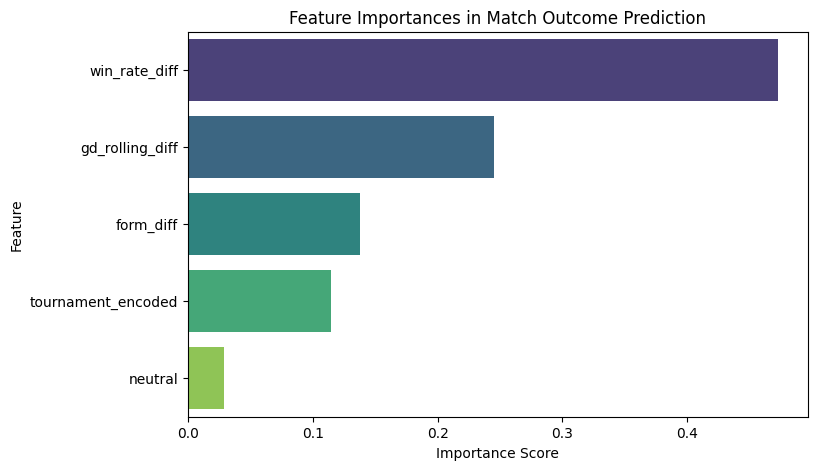

In [69]:
# Analyze feature importances
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances in Match Outcome Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

### 3.5 Confusion Matrix Visualization

A confusion matrix helps visualize how many matches are correctly predicted vs misclassified for each outcome class.

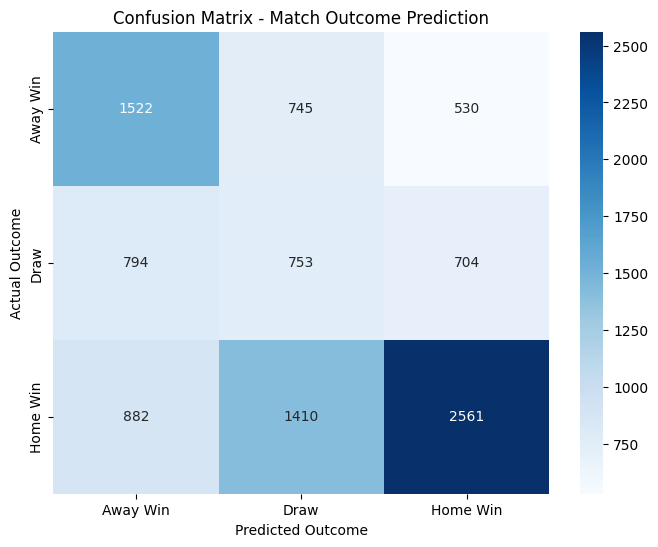

In [70]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_result.classes_, yticklabels=le_result.classes_)
plt.title('Confusion Matrix - Match Outcome Prediction')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.show()